## Notebook to compare single neuron morphologies with MAPseq dataset
Start by establishing dataframe

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [3]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK",
    "N040-685222-VM",
    "N066-685221-JN",
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index)

In [4]:
# Load data
df = clustering.build_length_df(dataDF, graphs, DATA_DIR, normalize_df=False)
df = df.drop(list(set(df.index) - set(dataDF["Graph"]))) # Drop graphs not included in dataDF
# Normalize length within each neuron
dfNorm = df.copy()
dfNorm = dfNorm.divide(dfNorm.sum(axis=1),axis=0)
# Merge dataframes
sorted_columns = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]
plotDF = dataDF.copy().merge(dfNorm[sorted_columns], left_on="Graph", right_index = True)

In [5]:
# Add total length
plotDF = plotDF.merge(pd.Series(df.sum(axis=1) / 1e4 , name = "Total Length (cm)"), left_on="Graph",right_index = True) # convert from microns to centimeters
plotDF["Norm Length"] = plotDF["Total Length (cm)"] / plotDF["Total Length (cm)"].max()

# Compute total axonal branches
axon_branch_dict = {}
for name in plotDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

# Add axonal branches to dataframe
plotDF = plotDF.merge(pd.Series(axon_branch_dict, name = "Axon Branches"), left_on = "Graph", right_index = True)
plotDF["Norm Branches"] = plotDF["Axon Branches"] / plotDF["Axon Branches"].max()

In [6]:
plotDF.head(3)

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,OLF,...,HY,MB,CB,P,MY,Other,Total Length (cm),Norm Length,Axon Branches,Norm Branches
2,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.6760,4571.1625,4612.8491,False,0.000000,...,0.020860,0.255037,0.000000,0.071944,0.338564,0.173288,14.318932,0.197319,103,0.066796
62,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.2172,4145.2136,4709.6842,True,0.047268,...,0.028757,0.040161,0.006982,0.004348,0.000000,0.009400,72.567420,1.000000,982,0.636835
63,N002-685222-HD,N002,685222,HD,Dbh-Cre-KI/wt,10559.8164,4318.4146,4715.9901,True,0.398272,...,0.018671,0.015920,0.004814,0.007940,0.000465,0.077648,49.870732,0.687233,809,0.524643


### Get subset of graphs within CCF bounds

In [119]:
# graph = graphs["N039-685221-YV"]
# graph = graphs["N025-685221-PG"]
# graph = graphs["N014-685221-YV"]
graph = graphs["N017-685221-HS"]

# Set position bounds
posBounds = np.arange(0,13000,1000)

# Assemble all nodes and edges
nodes = graph.nodes(data=True)
edges = graph.edges()

# Subset to nodes in cortex
ctxNodes = [n for n, d in nodes if id_to_roi[d.get("allen_id")] == acronym_to_id["Isocortex"]]

# Get length between various position bounds
posLength = {}
for i in range(len(posBounds)-1):
    useNodes = [n for n in ctxNodes if (graph.nodes[n]["pos"][0] > posBounds[i]) & (graph.nodes[n]["pos"][0] <= posBounds[i+1])]
    edgesInBounds = [(u, v) for u, v in edges if u in useNodes or v in useNodes]
    posLength[posBounds[i]] = sum(graph[u][v]['weight'] for u, v in edgesInBounds) / 10000
    

In [121]:
# graph = graphs["N039-685221-YV"]
# graph = graphs["N025-685221-PG"]
# graph = graphs["N014-685221-YV"]
# graph = graphs["N017-685221-HS"]

# Set position bounds
posBounds = np.arange(0,13000,1000)

# Initialize dict for storing results
graphPosDict = {}

for name, graph in graphs.items():
        
    # Assemble all nodes and edges
    nodes = graph.nodes(data=True)
    edges = graph.edges()
    
    # Subset to nodes in cortex
    ctxNodes = [n for n, d in nodes if id_to_roi[d.get("allen_id")] == acronym_to_id["Isocortex"]]
    
    # Get length between various position bounds
    posLength = {}
    for i in range(len(posBounds)-1):
        useNodes = [n for n in ctxNodes if (graph.nodes[n]["pos"][0] > posBounds[i]) & (graph.nodes[n]["pos"][0] <= posBounds[i+1])]
        edgesInBounds = [(u, v) for u, v in edges if u in useNodes or v in useNodes]
        posLength[posBounds[i]] = sum(graph[u][v]['weight'] for u, v in edgesInBounds) / 10000

    graphPosDict[name] = posLength

In [128]:
graphPosDict.keys()

dict_keys(['N003-685221-HS', 'N004-685221-BP', 'N001-685221-PG', 'N005-685221-JN', 'N009-685221-VM', 'N007-685221-BP', 'N010-685221-VM', 'N011-685221-SP', 'N014-685221-YV', 'N012-685221-SA', 'N016-685221-PG', 'N019-685221-HS', 'N018-685221-DS', 'N023-685221-JN', 'N026-685221-DS', 'N029-685221-JN', 'N032-685221-HS', 'N038-685221-HS', 'N028-685221-YV', 'N025-685221-PG', 'N033-685221-VM', 'N041-685221-JN', 'N037-685221-SP', 'N039-685221-YV', 'N048-685221-VM', 'N063-685221-HS', 'N047-685221-SA', 'N035-685221-DS', 'N008-685221-YP', 'N064-68221-JN', 'N054-685221-HS', 'N022-685221-YP', 'N015-685221-HD', 'N044-685221-DS', 'N017-685221-HS', 'N021-685221-HD', 'N053-685221-SP', 'N027-685221-SP', 'N052-685221-BP', 'N060-685221-YV', 'N056-685221-AK', 'N049-685221-SP', 'N040-685221-YP', 'N055-685221-JN', 'N050-685221-HD', 'N034-685221-VM', 'N020-685221-BP', 'N042-685221-HD', 'N065-685221-HD', 'N043-685221-HD', 'N045-685221-VM', 'N024-685221-VM', 'N036-685221-YP', 'N058-685221-JN', 'N051-685221-YP', 

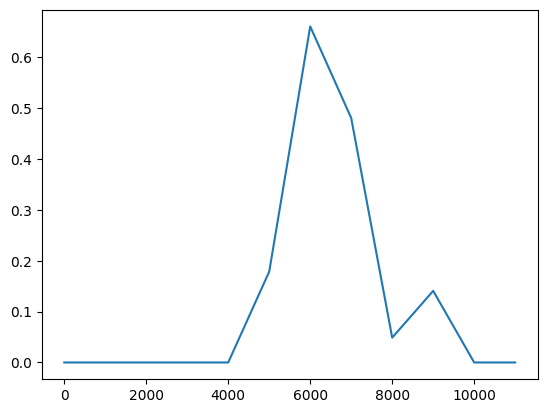

In [145]:
# name = "N039-685221-YV"
# name = "N025-685221-PG"
# name = "N014-685221-YV"
name = "N017-685221-HS"
posLength = graphPosDict[name]
plt.plot(posLength.keys(),posLength.values())

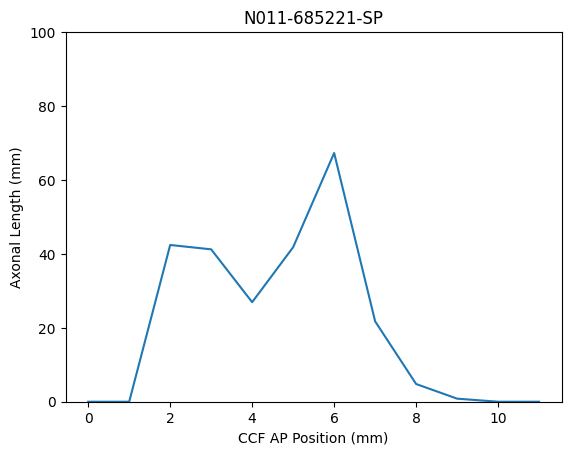

In [312]:
name = list(graphPosDict.keys())[7]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

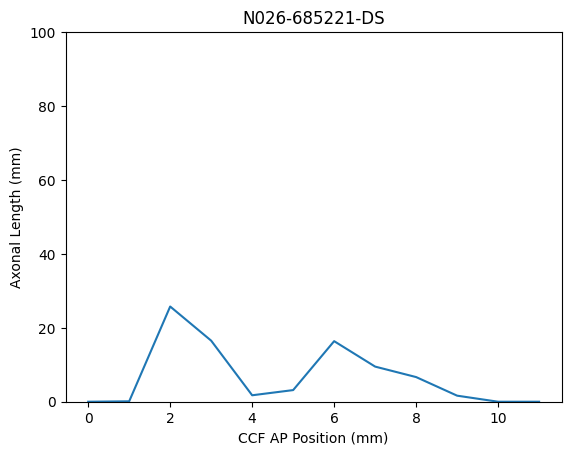

In [313]:
name = list(graphPosDict.keys())[14]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

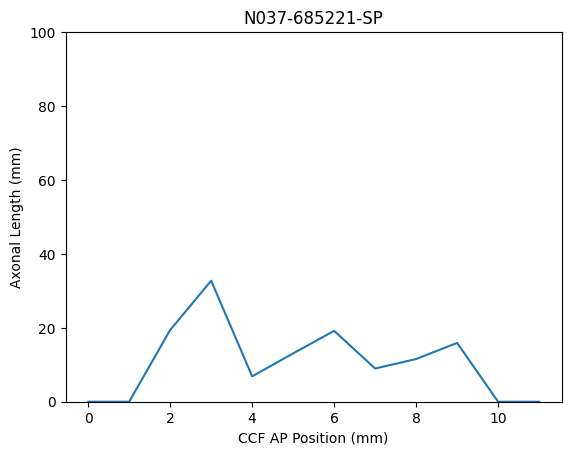

In [314]:
name = list(graphPosDict.keys())[22]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

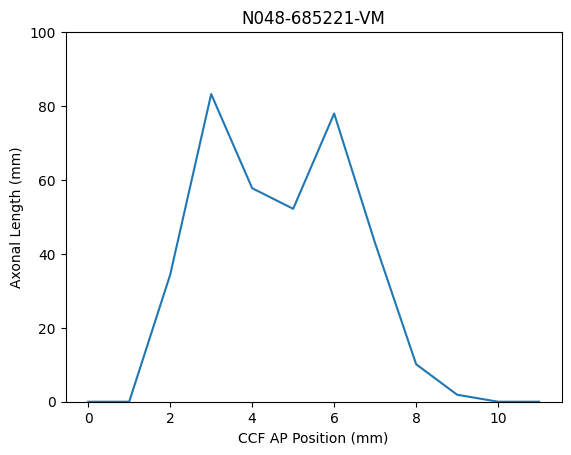

In [315]:
name = list(graphPosDict.keys())[24]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

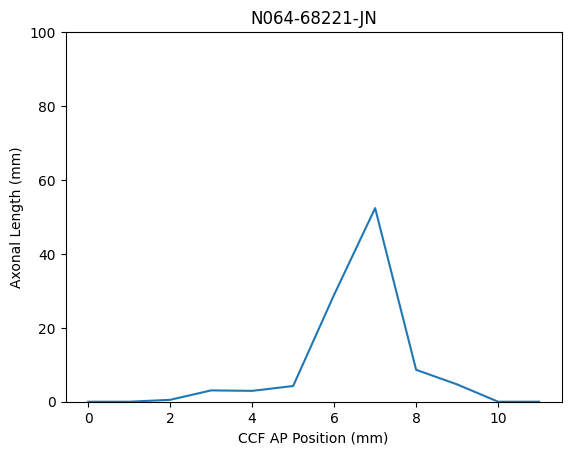

In [316]:
name = list(graphPosDict.keys())[29]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

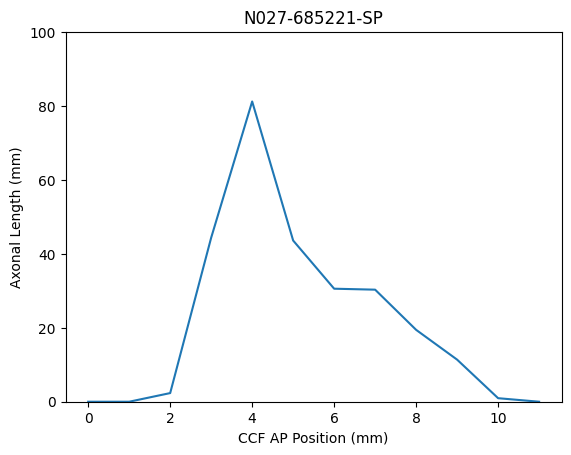

In [317]:
name = list(graphPosDict.keys())[37]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

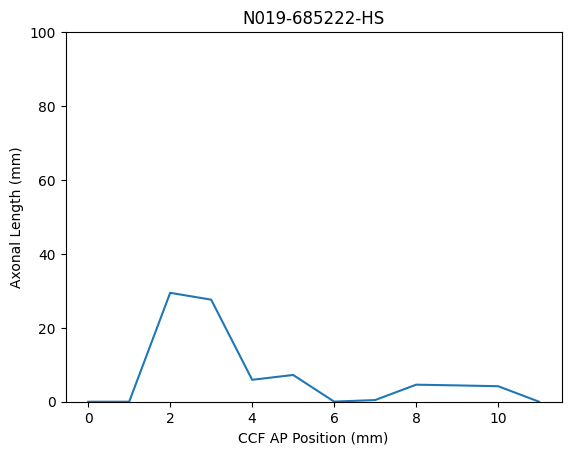

In [318]:
name = list(graphPosDict.keys())[71]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

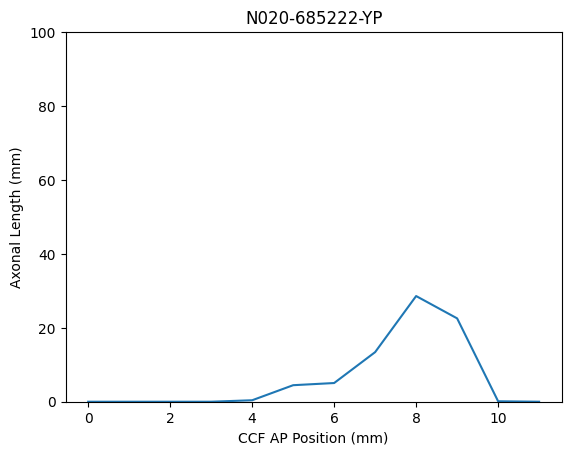

In [319]:
name = list(graphPosDict.keys())[72]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.ylim([0, 100])
plt.title(name);
plt.savefig(f"../results/virtual cortex slices {name}.png",dpi=300, bbox_inches='tight')

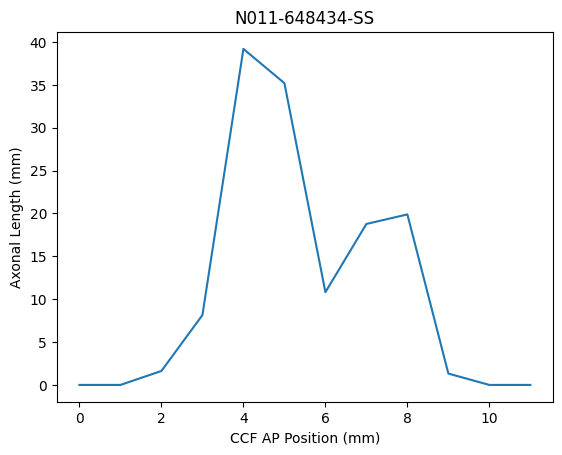

In [360]:
name = list(graphPosDict.keys())[109]
posLength = graphPosDict[name]
plt.plot(np.array(list(posLength.keys()))/1000,np.array(list(posLength.values())) * 10)
plt.ylabel("Axonal Length (mm)")
plt.xlabel("CCF AP Position (mm)")
plt.title(name);

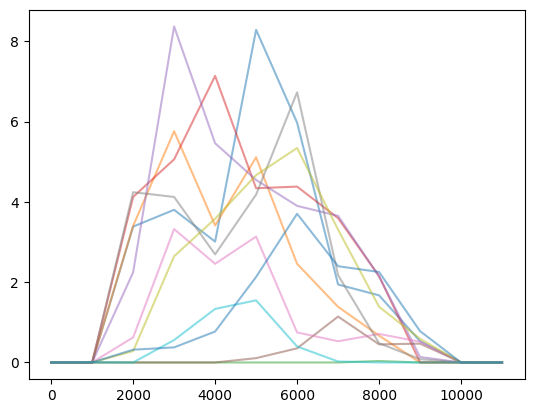

In [139]:
plt.figure()
i = 0
for name, posLength in graphPosDict.items():
    plt.plot(posLength.keys(),posLength.values(), alpha = .5)
    i = i + 1
    if i > 10:
        break

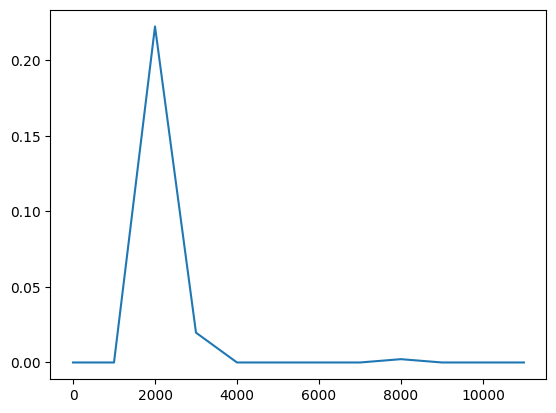

In [112]:
plt.plot(posLength.keys(),posLength.values())

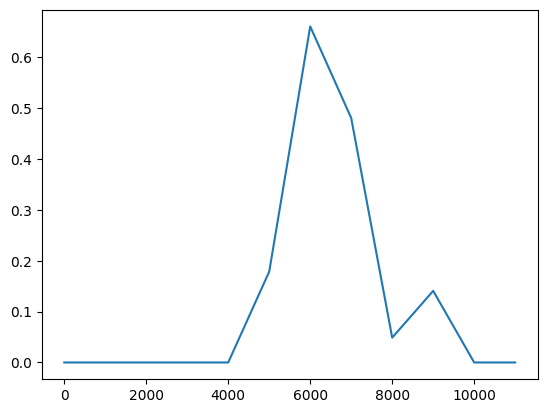

In [120]:
plt.plot(posLength.keys(),posLength.values())

In [368]:
## Save virtual slice dict (several hours of compute time as written)
import pickle

with open("../scratch/LC axon length virtual cortex slices.pkl","wb") as f:
    pickle.dump(graphPosDict,f)